<a href="https://colab.research.google.com/github/mdNotFound/100-days-of-ai-engineering/blob/main/Day2_FashionMNIST_using_TorchVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import matplotlib.pyplot as plt
import numpy as np

In [2]:
raw_train=torchvision.datasets.FashionMNIST(
    root="./data",
    train=True, #gives train data if false gives test data
    download=True, #if data not present in dir it will download the data
    transform=None #helps in transforming data
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.7MB/s]


In [3]:
raw_test=torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=None
)

In [4]:

len(raw_train)

60000

#### 60k training data

In [5]:
len(raw_test)

10000

#### 10k test data

In [6]:

raw_train[0]

(<PIL.Image.Image image mode=L size=28x28>, 9)

#### each image is 28 x 28

In [7]:
sample_image,sample_label=raw_train[0]
sample_label

9

In [8]:
sample_image

In [9]:
sample_array=np.array(sample_image) ## converting our sample image to array
print(sample_array)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

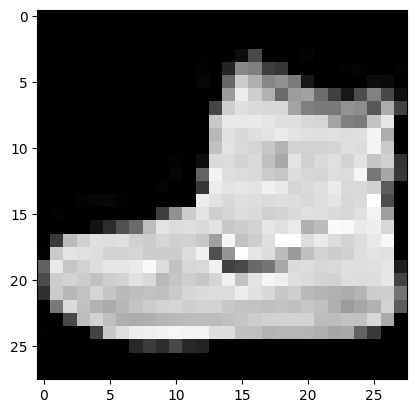

In [10]:
plt.imshow(sample_array,cmap="gray") ##image show helps with visualization of image and cmap helps to change the color
plt.show()

In [11]:
raw_train.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

#### 10 classes

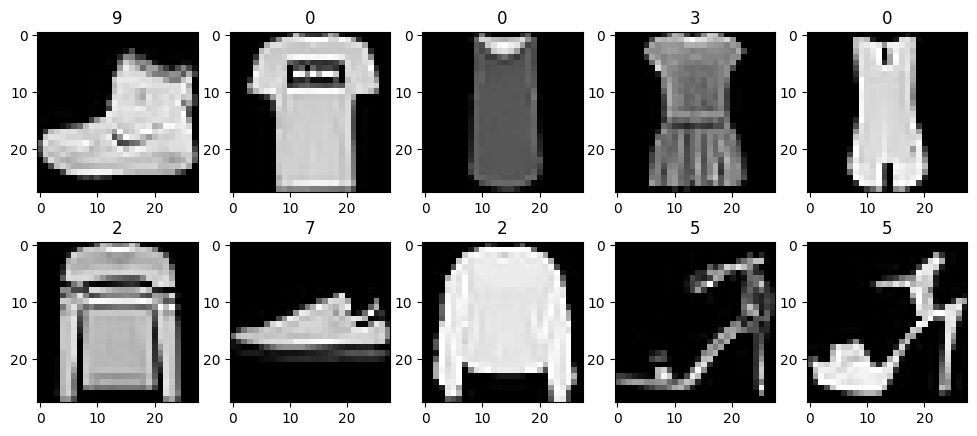

In [12]:
## 1 canvas prints 1 image
fig,ax=plt.subplots(2,5, figsize=(12,5))## 2 rows and 5 columns
## plot images in this canvas
for i, x in enumerate(ax.flat):
  image,label=raw_train[i]
  x.imshow(image,cmap="gray")
  x.set_title(label)
plt.show()

### preprocessing images

In [13]:
from torchvision.transforms import transforms
transform=transforms.Compose([
    transforms.ToTensor(), ## converts images to tensors
    transforms.Normalize(mean=(0.2860,),std=(0.3530,)) ## it takes a tuple so we need comma for a single value
])

In [14]:
full_train_dataset=torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

In [15]:
test_dataset=torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [16]:
##train_test_split from sklearn fails in huge data
TRAIN_SIZE=50000
VAL_SIZE=10000
from torch.utils.data import random_split
train_dataset,val_dataset=random_split(full_train_dataset,[TRAIN_SIZE,VAL_SIZE])

In [17]:
len(train_dataset)

50000

In [18]:
len(val_dataset)

10000

In [19]:
from torch.utils.data import DataLoader
BATCH_SIZE=128
train_loader=DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True ##the data is shuffled in every epoch
)

val_loader=DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader=DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [20]:
len(train_loader)

391

#### it has total 391 batches in 1 epoch u will go through 391 batches

In [21]:
images_batch,labels_batch=next(iter(train_loader)) ## storing one batch inside this variable just to look at it

In [22]:
images_batch.shape

torch.Size([128, 1, 28, 28])

In [23]:
labels_batch.shape

torch.Size([128])

### Building MLP classifier

In [24]:
#we need to flatten the image as mlp can only take 1d array not 2d
class Classifier(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten=nn.Flatten()
    self.layer1=nn.Linear(in_features=784,out_features=256)
    self.relu=nn.ReLU()
    self.layer2=nn.Linear(in_features=256,out_features=10)
  def forward(self,x):
    x=self.flatten(x)
    x=self.layer1(x)
    x=self.relu(x)
    x=self.layer2(x)
    return x

model=Classifier()
print(model) ## to see the architecture

Classifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=256, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=256, out_features=10, bias=True)
)


In [25]:
for name,param in model.named_parameters():
  print(f"name of the paramter: {name}, weight of the paramter:{param.size()}, graident status: {param.requires_grad}")

name of the paramter: layer1.weight, weight of the paramter:torch.Size([256, 784]), graident status: True
name of the paramter: layer1.bias, weight of the paramter:torch.Size([256]), graident status: True
name of the paramter: layer2.weight, weight of the paramter:torch.Size([10, 256]), graident status: True
name of the paramter: layer2.bias, weight of the paramter:torch.Size([10]), graident status: True


In [26]:
pip install torchinfo

In [27]:
from torchinfo import summary
summary(model,input_size=(128,1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
Classifier                               [128, 10]                 --
├─Flatten: 1-1                           [128, 784]                --
├─Linear: 1-2                            [128, 256]                200,960
├─ReLU: 1-3                              [128, 256]                --
├─Linear: 1-4                            [128, 10]                 2,570
Total params: 203,530
Trainable params: 203,530
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 26.05
Input size (MB): 0.40
Forward/backward pass size (MB): 0.27
Params size (MB): 0.81
Estimated Total Size (MB): 1.49

In [28]:
class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten=nn.Flatten()
    self.layer1=nn.Linear(in_features=784,out_features=512)
    self.relu=nn.ReLU()
    self.dropout=nn.Dropout(p=0.02)
    self.layer2=nn.Linear(in_features=512,out_features=256)
    self.relu=nn.ReLU()
    self.dropout=nn.Dropout(p=0.02)
    self.layer3=nn.Linear(in_features=256,out_features=10)
  def forward(self,x):
    x=self.flatten(x)
    x=self.layer1(x)
    x=self.relu(x)
    x=self.layer2(x)
    return x

model1=MLP()
print(model1)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=512, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.02, inplace=False)
  (layer2): Linear(in_features=512, out_features=256, bias=True)
  (layer3): Linear(in_features=256, out_features=10, bias=True)
)


In [29]:
loss_fn=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)

In [30]:
def train_one_epoch(model,train_loader,loss_fn,optimizer):
  model.train()
  total_loss=0
  correct=0
  total=0
  for images,labels in train_loader:
    optimizer.zero_grad()
    outputs=model(images)
    loss=loss_fn(outputs,labels)
    loss.backward()##backpropogation
    optimizer.step()
    total_loss+=loss.item()
    predicted=outputs.argmax(dim=1)
    correct+=(predicted==labels).sum().item()
    total+= len(labels)
  avg_loss=total_loss/len(train_loader)
  accuracy=(correct/total)*100
  return avg_loss,accuracy

In [31]:
from functools import total_ordering
def validate(model,val_loader,loss_fn):
  model.eval()
  total_loss=0
  correct=0
  total=0
  with torch.no_grad():
    for images,labels in val_loader:
      outputs=model(images)
      loss=loss_fn(outputs,labels)
      total_loss+=loss.item()
      predicted=outputs.argmax(dim=1)
      total+=len(labels)
      correct+=(predicted==labels).sum().item()
  avg_loss=total_loss/len(val_loader)
  accuracy=(correct/total)*100
  return avg_loss,accuracy

In [32]:
NUM_EPOCHS=5
train_losses=[]
train_accuracy=[]
val_losses=[]
val_accuracy=[]

for epoch in range(NUM_EPOCHS):
  train_loss,train_acc=train_one_epoch(model,train_loader,loss_fn,optimizer)
  val_loss,val_acc=validate(model,val_loader,loss_fn)
  train_losses.append(train_loss)
  train_accuracy.append(train_acc)
  val_losses.append(val_loss)
  val_accuracy.append(val_acc)
  print(f"Epoch {epoch+1}/{NUM_EPOCHS}, Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}%, Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}%")
print("training completed")

Epoch 1/5, Train Loss: 0.4922, Train Accuracy: 82.2300%, Val Loss: 0.3854, Val Accuracy: 86.1700%
Epoch 2/5, Train Loss: 0.3613, Train Accuracy: 86.9000%, Val Loss: 0.3575, Val Accuracy: 86.9900%
Epoch 3/5, Train Loss: 0.3198, Train Accuracy: 88.2580%, Val Loss: 0.3293, Val Accuracy: 88.1100%
Epoch 4/5, Train Loss: 0.2946, Train Accuracy: 89.1000%, Val Loss: 0.3262, Val Accuracy: 88.0700%
Epoch 5/5, Train Loss: 0.2700, Train Accuracy: 89.9960%, Val Loss: 0.3139, Val Accuracy: 88.6400%
training completed
